In [1]:
import os
import sys

import numpy as np

In [2]:
sys.path.append(os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "cvf-analysis"))

utils_path = os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "utils")
sys.path.append(utils_path)

from plot_graphs import plot
from command_line_helpers import get_graph

In [3]:
graph_name = "graph_random_regular_graph_n8_d4"
_, graph = next(get_graph([graph_name]))
graph

{0: {1, 3, 5, 7},
 1: {0, 3, 4, 6},
 2: {3, 4, 5, 7},
 3: {0, 1, 2, 4},
 4: {1, 2, 3, 6},
 5: {0, 2, 6, 7},
 6: {1, 4, 5, 7},
 7: {0, 2, 5, 6}}

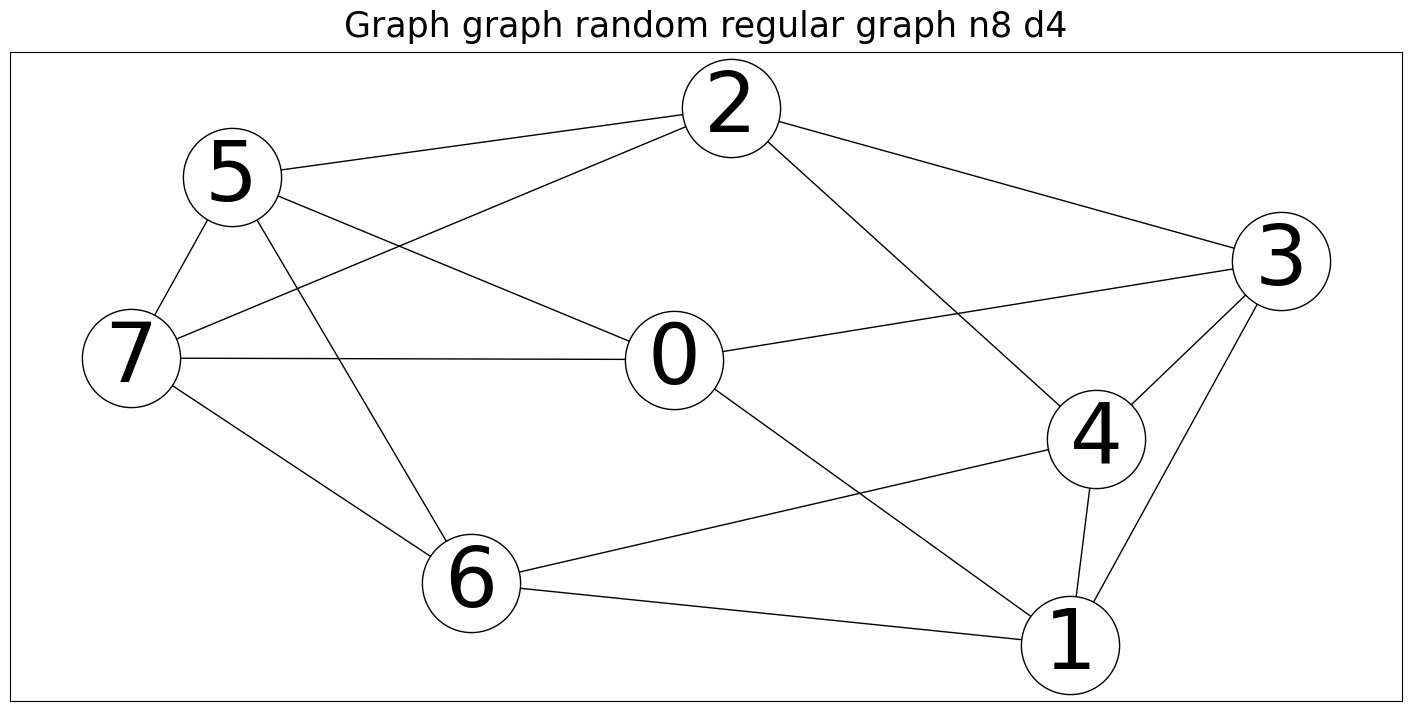

In [4]:
plot([graph_name])

# Page Rank convergence formula

$PR(P_i) = \frac{1 - d}{N} + d \sum_{P_j \in M(P_i)} \frac{PR(P_j)}{L(P_j)}$

In [ ]:
d = 0.85
tol = 1e-8

In [6]:
N = len(graph)
print("No. of nodes:", N)

No. of nodes: 8


# Initial PR values

In [7]:
PR = np.full(N, 1/N)
PR

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

# Iterations

In [8]:
itr = 1
while True:
    PR_new = []
    converged = True
    for n in range(N):
        temp = (1-d)/N + d * np.sum([ PR[nbr]/len(graph[nbr]) for nbr in graph[n] ])
        PR_new.append(temp)
        if abs(temp - PR[n]) > tol:
            converged = False
    PR = np.array(PR_new)
    if converged:
        print("Converged on the Iteration:", itr)
        break
    itr += 1


Converged on the Iteration: 1


# Page Rank scores

In [9]:
PR

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

# Sorted Page Rank Scores

In [10]:
dict(sorted(enumerate(PR), key=lambda x: x[1], reverse=True))

{0: np.float64(0.125),
 1: np.float64(0.125),
 2: np.float64(0.125),
 3: np.float64(0.125),
 4: np.float64(0.125),
 5: np.float64(0.125),
 6: np.float64(0.125),
 7: np.float64(0.125)}